In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

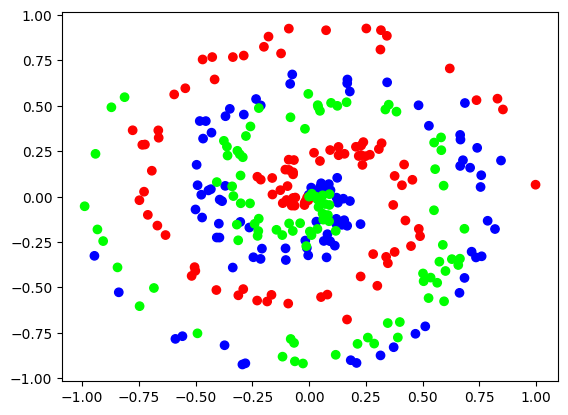

In [24]:
#! pip install nnfs


from nnfs.datasets import spiral_data
X ,y = spiral_data(100,3)

plt.scatter(X[:,0],X[:,1],c=y,cmap='brg')

In [30]:
# class implementing the dense layers
class DenseLayer:
  def __init__(self,n_inputs,n_neurons) -> None:
    self.weights = 0.1 * np.random.randn(n_inputs,n_neurons)
    self.bias = np.zeros((1,n_neurons))

  def forward(self,X):
    self.inputs = X
    self.output = self.inputs@self.weights + self.bias
    return self.output

  def backward(self,dvalues):
    self.dweights = self.inputs.T @ dvalues
    self.dbias = np.sum(dvalues,axis=0,keepdims=True)
    self.dinputs = dvalues@self.weights.T

In [31]:
# class implementing Relu
class ReLU:
  def forward(self,inputs):
    self.inputs = inputs
    self.output = np.maximum(0,self.inputs)
  def backward(self,dvalues):
    relu_derivative =  np.where(self.inputs>0,1,0)
    self.dinputs = dvalues * relu_derivative
    return self.dinputs


In [32]:
# class implementing Softmax and Categorical cross entropy

class SoftmaxCrossEntropy:
  def SoftMax_forward(self,weighted_sum):   # this makes the predictions : e^z1 / e^z1 + e^z2 + e^z3
    # subtract the maximum of each row from each number
    shifted = weighted_sum - np.max(weighted_sum ,axis =1 , keepdims = True)
    # get exponents of each value
    exp_weighted_sum = np.exp(shifted)
    self.output =  exp_weighted_sum / np.sum(exp_weighted_sum,axis=1,keepdims=True)
    return self.output

  def CC_forward(self,softmax_output,true_labels):    # this gets the loss : categorical cross entropy -> summation yilog(yi_hat)
    # convert the true_labels into one hot encoding if not given
    samples,classes = softmax_output.shape
    if len(true_labels.shape)==1:
      true_labels = np.eye(classes)[true_labels]
    # clip to prevent log(0)
    clipped = np.clip(softmax_output,1e-7,1-1e-7)
    corrected_confidence = np.sum(clipped*true_labels,axis=1)
    negative_log_likelihood = -np.log(corrected_confidence)
    return np.mean(negative_log_likelihood)

  def backward(self,y_true,y_pred):
    # partial differentiation of the loss wrt the weights (DL_Dz) is given by y_True-y_pred
    samples  = y_pred.shape[0]
    classes = y_pred.shape[1]
    if len(y_true.shape) == 1 : # ohe the true matrix , if not
      y_true = np.eye(classes)[y_true]
    Dloss_Dz = y_pred - y_true    # dloss_dz is the difference of the pred and true
    Dloss_Dz /= samples  # divide by number of samples to normalize
    return Dloss_Dz


In [41]:
# creating the model
dense1 = DenseLayer(2,64)
dense2 = DenseLayer(64,3)
relu = ReLU()
sce = SoftmaxCrossEntropy()

for i in range(10000):
  # forward pass
  dense1.forward(X)
  relu.forward(dense1.output)
  dense2.forward(relu.output)
  y_pred = sce.SoftMax_forward(dense2.output)

  loss = sce.CC_forward(y_pred,y)

  # backward pass
  dloss_dz2 = sce.backward(y,y_pred)
  dense2.backward(dloss_dz2)
  dloss_dz1 = relu.backward(dense2.dinputs)
  dense1.backward(dloss_dz1)

  lr = 1.0
  dense1.weights -= lr * dense1.dweights
  dense1.bias -= lr * dense1.dbias

  dense2.weights -= lr * dense2.dweights
  dense2.bias -= lr * dense2.dbias

  if i % 100 == 0:
    predictions = np.argmax(y_pred, axis=1)
    acc = np.mean(predictions == y)
    print(f"epoch : {i},Loss: {loss:.4f}, Acc: {acc:.4f}")




epoch : 0,Loss: 1.0965, Acc: 0.3333
epoch : 100,Loss: 1.0600, Acc: 0.4400
epoch : 200,Loss: 1.0553, Acc: 0.4467
epoch : 300,Loss: 1.0523, Acc: 0.4533
epoch : 400,Loss: 1.0489, Acc: 0.4700
epoch : 500,Loss: 1.0439, Acc: 0.4700
epoch : 600,Loss: 1.0368, Acc: 0.5000
epoch : 700,Loss: 1.0281, Acc: 0.5100
epoch : 800,Loss: 1.0180, Acc: 0.5167
epoch : 900,Loss: 1.0228, Acc: 0.4700
epoch : 1000,Loss: 1.0268, Acc: 0.4367
epoch : 1100,Loss: 1.0224, Acc: 0.4267
epoch : 1200,Loss: 1.0231, Acc: 0.4533
epoch : 1300,Loss: 1.0107, Acc: 0.4433
epoch : 1400,Loss: 1.0180, Acc: 0.4500
epoch : 1500,Loss: 1.0141, Acc: 0.4567
epoch : 1600,Loss: 0.9982, Acc: 0.4867
epoch : 1700,Loss: 1.0032, Acc: 0.4500
epoch : 1800,Loss: 0.9834, Acc: 0.5033
epoch : 1900,Loss: 0.9692, Acc: 0.4700
epoch : 2000,Loss: 0.9772, Acc: 0.5467
epoch : 2100,Loss: 0.9906, Acc: 0.4800
epoch : 2200,Loss: 0.9927, Acc: 0.4567
epoch : 2300,Loss: 0.9734, Acc: 0.5167
epoch : 2400,Loss: 0.9619, Acc: 0.5067
epoch : 2500,Loss: 0.9757, Acc: 0.533